<div style="font-size: 0.6em; max-width: 70ch">

# Importing packages

</div>


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from mplcursors import cursor
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import statsmodels
import os
from itertools import combinations
import plotly.io as pio

pio.renderers.default = "notebook_connected"
from IPython.display import display, HTML

# js = '<script src="https://cdnjs.cloudflare.com/ajax/libs/require.js/2.3.6/require.min.js" integrity="sha512-c3Nl8+7g4LMSTdrm621y7kf9v3SDPnhxLNhcjFJbKECVnmZHTdo+IRO05sNLTH/D3vA6u1X32ehoLC7WFVdheg==" crossorigin="anonymous"></script>'
# display(HTML(js))
import ardalan_proEV_functions as AF
# from termcolor import colored

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
import sys

import scbig.core as scbd

<div style="font-size: 0.6em; max-width: 100ch">

# Importing the cleaned and normalized date

</div>


In [ ]:
import_path = "../data"

# Note:  Instead of this file, use the sample file. I have create 
df_control = pd.read_csv(
    import_path + "/LOPAC_Controls_single cell.csv", low_memory=False
)
# df_Sample = pd.read_csv(
#     import_path + "/LOPAC_Samples_single cell_2024.csv", low_memory=False
# )

# Clean the name of the columns in the control dataframe
df_control, _ = scbd.clean_variable_names(df_control)

# variables to be used for exporting figures
output_folder = (
    "../data/output"
)
library_name = "LOPAC"

In [6]:
df_control.head()

,Unnamed: 0,Plate format,File ID,LOPAC_Compounds,EV-uptake_Normalized_by_mean,Number of Spots per Area of Individual cells,Number of Spots,Nucleus Area [um2],Nucleus Roundness,Nucleus Perimeter [um],Nucleus Width [um],Nucleus Length [um],Nucleus Ratio Width to Length,Nucleus HOECHST 33342 Haralick Correlation 1 px,Nucleus HOECHST 33342 Haralick Contrast 1 px,Nucleus HOECHST 33342 Haralick Sum Variance 1 px,Nucleus HOECHST 33342 Haralick Homogeneity 1 px,Nucleus HOECHST 33342 SER Spot 0 px,Nucleus HOECHST 33342 SER Hole 0 px,Nucleus HOECHST 33342 SER Edge 0 px,Nucleus HOECHST 33342 SER Ridge 0 px,Nucleus HOECHST 33342 SER Valley 0 px,Nucleus HOECHST 33342 SER Saddle 0 px,Nucleus HOECHST 33342 SER Bright 0 px,Nucleus HOECHST 33342 SER Dark 0 px,Intensity Nucleus HOECHST 33342 Mean,Intensity Nucleus HOECHST 33342 StdDev,Intensity Nucleus HOECHST 33342 Median,Intensity Nucleus HOECHST 33342 Sum,Individual cells Area [um2],Individual cells Roundness,Individual cells Width [um],Individual cells Length [um],Individual cells Ratio Width to Length,Membrane Symmetry 02,Membrane Symmetry 03,Membrane Symmetry 04,Membrane Symmetry 05,Membrane Symmetry 12,Membrane Symmetry 13,Membrane Symmetry 14,Membrane Symmetry 15,Membrane Threshold Compactness 30%,Membrane Threshold Compactness 40%,Membrane Threshold Compactness 50%,Membrane Threshold Compactness 60%,Membrane Axial Small Length,Membrane Axial Length Ratio,Membrane Radial Mean,Membrane Radial Relative Deviation,Membrane Profile 4/5,Membrane Symmetry 02 SP-Filter,Membrane Symmetry 03 SP-Filter,Membrane Symmetry 04 SP-Filter,Membrane Symmetry 05 SP-Filter,Membrane Symmetry 12 SP-Filter,Membrane Symmetry 13 SP-Filter,Membrane Symmetry 14 SP-Filter,Membrane Symmetry 15 SP-Filter,Membrane Threshold Compactness 30% SP-Filter,Membrane Threshold Compactness 40% SP-Filter,Membrane Threshold Compactness 50% SP-Filter,Membrane Threshold Compactness 60% SP-Filter,Membrane Axial Small Length SP-Filter,Membrane Axial Length Ratio SP-Filter,Membrane Radial Mean SP-Filter,Membrane Radial Relative Deviation SP-Filter,Membrane Radial Mean Ratio SP-Filter,Membrane Profile 4/5 SP-Filter,Membrane Symmetry 02 SER-Bright,Membrane Symmetry 03 SER-Bright,Membrane Symmetry 04 SER-Bright,Membrane Symmetry 05 SER-Bright,Membrane Symmetry 12 SER-Bright,Membrane Symmetry 13 SER-Bright,Membrane Symmetry 14 SER-Bright,Membrane Symmetry 15 SER-Bright,Membrane Threshold Compactness 30% SER-Bright,Membrane Threshold Compactness 40% SER-Bright,Membrane Threshold Compactness 50% SER-Bright,Membrane Threshold Compactness 60% SER-Bright,Membrane Axial Small Length SER-Bright,Membrane Axial Length Ratio SER-Bright,Membrane Radial Mean SER-Bright,Membrane Radial Relative Deviation SER-Bright,Membrane Radial Mean Ratio SER-Bright,Membrane Profile 4/5 SER-Bright,Membrane Symmetry 02 SER-Dark,Membrane Symmetry 03 SER-Dark,Membrane Symmetry 04 SER-Dark,Membrane Symmetry 05 SER-Dark,Membrane Symmetry 12 SER-Dark,Membrane Symmetry 13 SER-Dark,Membrane Symmetry 14 SER-Dark,Membrane Symmetry 15 SER-Dark,Membrane Threshold Compactness 30% SER-Dark,Membrane Threshold Compactness 40% SER-Dark,Membrane Threshold Compactness 50% SER-Dark,Membrane Threshold Compactness 60% SER-Dark,Membrane Axial Small Length SER-Dark,Membrane Axial Length Ratio SER-Dark,Membrane Radial Mean SER-Dark,Membrane Radial Relative Deviation SER-Dark,Membrane Radial Mean Ratio SER-Dark,Membrane Profile 4/5 SER-Dark,Membrane Symmetry 02 SER-Ridge,Membrane Symmetry 03 SER-Ridge,Membrane Symmetry 04 SER-Ridge,Membrane Symmetry 05 SER-Ridge,Membrane Symmetry 12 SER-Ridge,Membrane Symmetry 13 SER-Ridge,Membrane Symmetry 14 SER-Ridge,Membrane Symmetry 15 SER-Ridge,Membrane Threshold Compactness 30% SER-Ridge,Membrane Threshold Compactness 40% SER-Ridge,Membrane Threshold Compactness 50% SER-Ridge,Membrane Threshold Compactness 60% SER-Ridge,Membrane Axial Small Length SER-Ridge,Membrane Axial Length Ratio SER-Ridge,Membrane Radial Mean SER-Ridge,Membrane Radial Relative 

<div style="font-size: 0.6em; max-width: 100ch">

# Data visualization

</div>

In [7]:
df_control.columns.tolist()

['Unnamed: 0',
 'Plate format',
 'File ID',
 'LOPAC_Compounds',
 'EV-uptake_Normalized_by_mean',
 'Number of Spots per Area of Individual cells',
 'Number of Spots',
 'Nucleus Area [um2]',
 'Nucleus Roundness',
 'Nucleus Perimeter [um]',
 'Nucleus Width [um]',
 'Nucleus Length [um]',
 'Nucleus Ratio Width to Length',
 'Nucleus HOECHST 33342 Haralick Correlation 1 px',
 'Nucleus HOECHST 33342 Haralick Contrast 1 px',
 'Nucleus HOECHST 33342 Haralick Sum Variance 1 px',
 'Nucleus HOECHST 33342 Haralick Homogeneity 1 px',
 'Nucleus HOECHST 33342 SER Spot 0 px',
 'Nucleus HOECHST 33342 SER Hole 0 px',
 'Nucleus HOECHST 33342 SER Edge 0 px',
 'Nucleus HOECHST 33342 SER Ridge 0 px',
 'Nucleus HOECHST 33342 SER Valley 0 px',
 'Nucleus HOECHST 33342 SER Saddle 0 px',
 'Nucleus HOECHST 33342 SER Bright 0 px',
 'Nucleus HOECHST 33342 SER Dark 0 px',
 'Intensity Nucleus HOECHST 33342 Mean',
 'Intensity Nucleus HOECHST 33342 StdDev',
 'Intensity Nucleus HOECHST 33342 Median',
 'Intensity Nucleus H

In [ ]:
# Set the input data for the scatter plot generator

selected_x_cols = [
    "Individual cells Area [um2]",
    "Intensity Nucleus HOECHST 33342 Sum",  
    "Membrane Radial Mean",    
    # "EV-uptake_Normalized_by_mean", # same name in AI files
]

selected_y_cols = ["Number of Spots"]

output_folder = (
    "../data/output"
)

save_figs = False   
library_name = "LOPAC"

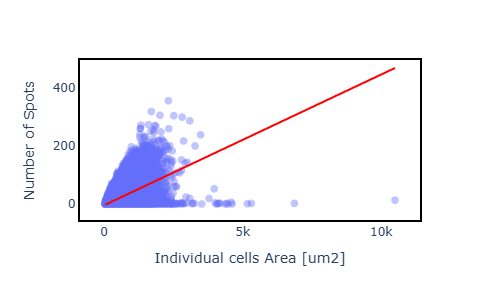

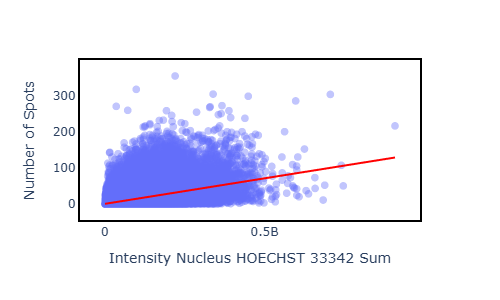

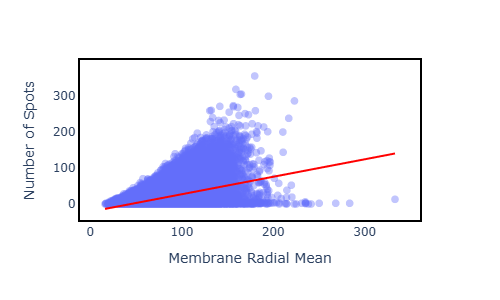

In [9]:
scbd.scatter_plot_gen(
    df_control, 
    mode="x_vs_y",  # controls how pairs are generated
    x_cols=selected_x_cols, 
    y_col=selected_y_cols[0],
    # plotting params
    s=8,  # scatter marker size
    alpha=0.4,  # scatter point transparency
    legend_size=18,  # legend font size
    x_label_size=14,  # x-axis label font size
    y_label_size=14,  # y-axis label font size
    tick_size=12,  # tick label font size
    draw_regression=True, 
    # saving
    save_figs=save_figs,  # if True save PNGs; if False display interactively
    output_folder=output_folder,  
    file_prefix="scatter", 
    library_name=library_name,  # optional extra prefix for file name  
    render_mode="static",
    width=500,
    height=300
)

<div style="font-size: 0.6em; max-width: 100ch">

# Distribution of EV-uptake in single cells (Control)

</div>

In [12]:
scbd.hist_plot_gen(
     df_control,
    cols=["EV-uptake_Normalized_by_mean"],
    discont_y_axis=[8000, 20000],  # break from 500 → 2000
    nbins=50,
)